<a href="https://colab.research.google.com/github/carlohermosa/sales-data-analysis/blob/main/sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd

# Load the dataset
sales_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Sales_data_analysis/python_sales_analysis_dataset.csv')
pd.options.display.float_format = "{:,.2f}".format

In [31]:
# Inspect the dataset
sales_df.head()
sales_df.shape
sales_df.columns
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1508 entries, 0 to 1507
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1508 non-null   object 
 1   Order_Date        1508 non-null   object 
 2   Customer_ID       1508 non-null   object 
 3   Customer_Segment  1508 non-null   object 
 4   Region            1508 non-null   object 
 5   City              1508 non-null   object 
 6   Category          1508 non-null   object 
 7   Product           1508 non-null   object 
 8   Quantity          1508 non-null   int64  
 9   Unit_Price        1508 non-null   float64
 10  Discount          1508 non-null   float64
 11  Sales             1508 non-null   float64
 12  Total_Cost        1508 non-null   float64
 13  Profit            1508 non-null   float64
 14  Sales_Channel     1508 non-null   object 
 15  Payment_Method    1508 non-null   object 
 16  Customer_Rating   1323 non-null   float64


In [32]:
# Quantify missing values
sales_df.isna().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Segment,0
Region,0
City,0
Category,0
Product,0
Quantity,0
Unit_Price,0


In [33]:
# Show all duplicate rows
sales_df[sales_df.duplicated(keep=False)]

# Remove duplicate rows
sales_df = sales_df.drop_duplicates()

# Check new dataset size
sales_df.shape

(1500, 17)

In [34]:
# Check city values
sales_df['City'].unique()

# Remove extra spaces
sales_df['City'] = sales_df['City'].str.strip()

# Verify city values
sales_df['City'].unique()

array(['Calgary', 'Vancouver', 'Toronto', 'Winnipeg', 'Halifax',
       'Montreal', 'Ottawa', 'Victoria', 'Quebec City'], dtype=object)

In [35]:
# Check category values
sales_df['Category'].unique()

# Standard capitalization
sales_df['Category'] = sales_df['Category'].str.title()

# Verify category values
sales_df['Category'].unique()

array(['Accessories', 'Furniture', 'Electronics'], dtype=object)

In [54]:
# Convert to datetime
sales_df['Order_Date'] = pd.to_datetime(sales_df['Order_Date'])

# Check datatype
sales_df['Order_Date'].dtype

dtype('<M8[ns]')

In [55]:
# Check dataset size
sales_df.shape

# Check duplicate count
sales_df.duplicated().sum()

# Check missing values
sales_df.isna().sum()

# Check data types
sales_df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Customer_ID,object
Customer_Segment,object
Region,object
City,object
Category,object
Product,object
Quantity,int64
Unit_Price,float64


In [38]:
# Check lowest sales value
sales_df['Sales'].min()

30.66

In [39]:
# Count zero sales
(sales_df['Sales'] == 0).sum()

np.int64(0)

In [56]:
# Create profit margin percentage
sales_df['Profit_Margin'] = sales_df['Profit'] / sales_df['Sales'] * 100

# Preview profit margin values
sales_df[['Sales','Profit','Profit_Margin']].head()

,Sales,Profit,Profit_Margin
0,81.36,43.36,53.29
1,72.31,44.31,61.28
2,527.59,197.59,37.45
3,235.49,125.49,53.29
4,134.33,78.33,58.31


In [41]:
# Round the profit margin
sales_df['Profit_Margin'] = sales_df['Profit_Margin'].round(2)

# Preview profit margin values
sales_df[['Sales','Profit','Profit_Margin']].head()

,Sales,Profit,Profit_Margin
0,81.36,43.36,53.29
1,72.31,44.31,61.28
2,527.59,197.59,37.45
3,235.49,125.49,53.29
4,134.33,78.33,58.31


In [42]:
# Create order year
sales_df['Order_Year'] = sales_df['Order_Date'].dt.year

# Create order month number
sales_df['Order_Month'] = sales_df['Order_Date'].dt.month

# Create order month name
sales_df['Order_Month_Name'] = sales_df['Order_Date'].dt.month_name()

# Preview date features
sales_df[['Order_Date','Order_Year','Order_Month','Order_Month_Name']].head()

,Order_Date,Order_Year,Order_Month,Order_Month_Name
0,2025-04-25,2025,4,April
1,2025-01-31,2025,1,January
2,2025-01-07,2025,1,January
3,2025-09-28,2025,9,September
4,2025-03-13,2025,3,March


In [43]:
# Sum sales by region
region_sales = sales_df.groupby('Region')['Sales'].sum()

# Sort highest to lowest
region_sales = region_sales.sort_values(ascending=False)

# Show result
region_sales

,Sales
Region,
West,"367,421.20"
East,"364,574.92"
Central,"360,916.55"


In [44]:
# Calculate total sales
total_sales = sales_df['Sales'].sum()

# Calculate regional sales share
regional_sales_share = region_sales / total_sales * 100

# Show result
regional_sales_share

,Sales
Region,
West,33.62
East,33.36
Central,33.02


In [45]:
# Compare profit by region
regional_profit = sales_df.groupby('Region')['Profit'].sum()

# Sort highest to lowest
regional_profit = regional_profit.sort_values(ascending=False)

# Show result
regional_profit

,Profit
Region,
East,"136,641.92"
Central,"136,569.55"
West,"128,648.20"


In [46]:
# Calculate average profit margin by region
regional_profit_margin = sales_df.groupby('Region')['Profit_Margin'].mean()

# Sort highest to lowest
regional_profit_margin = regional_profit_margin.sort_values(ascending=False)

# Round values
regional_profit_margin = regional_profit_margin.round(2)

# Show result
regional_profit_margin

,Profit_Margin
Region,
East,46.64
Central,45.70
West,45.15


In [47]:
# Calculate average discount by region
average_discount_by_region = sales_df.groupby('Region')['Discount'].mean()

# Convert to percentage
average_discount_by_region = average_discount_by_region * 100

# Round values
average_discount_by_region = average_discount_by_region.round(2)

# Sort highest to lowest
average_discount_by_region = average_discount_by_region.sort_values(ascending=False)

# Show result
average_discount_by_region


,Discount
Region,
West,6.49
Central,6.00
East,5.88


In [48]:
# Calculate correlation
discount_margin_correlation = sales_df['Discount'].corr(sales_df['Profit_Margin'])

# Round correlation
discount_margin_correlation = discount_margin_correlation.round(2)

# Show result
discount_margin_correlation

np.float64(-0.3)

In [49]:
# Sum profit by category
category_profit = sales_df.groupby('Category')['Profit'].sum()

# Sort highest to lowest
category_profit = category_profit.sort_values(ascending=False)

# Show result
category_profit

,Profit
Category,
Electronics,"200,134.92"
Furniture,"135,126.19"
Accessories,"66,598.56"


In [50]:
# Sum sales and profit by category
category_summary = sales_df.groupby('Category')[['Sales','Profit']].sum()

# Calculate weighted margin
category_summary['Profit_Margin'] = (
    category_summary['Profit'] / category_summary['Sales'] * 100
).round(2)

# Sort by profit
category_summary = category_summary.sort_values(by='Profit', ascending=False)

# Round values
category_summary = category_summary.round(2)

# Show result
category_summary.reset_index()

,Category,Sales,Profit,Profit_Margin
0,Electronics,"615,692.92","200,134.92",32.51
1,Furniture,"361,741.19","135,126.19",37.35
2,Accessories,"115,478.56","66,598.56",57.67


In [51]:
# Compare profit margin by category
category_profit_margin = sales_df.groupby('Category')['Profit_Margin'].mean()

# Sort highest to lowest
category_profit_margin = category_profit_margin.sort_values(ascending=False)

# Round values
category_profit_margin = category_profit_margin.round(2)

# Show result
category_profit_margin

,Profit_Margin
Category,
Accessories,58.07
Electronics,38.52
Furniture,37.63


In [57]:
# Summarize sales and profit by channel
channel_summary = sales_df.groupby('Sales_Channel')[['Sales','Profit']].sum()

# Sort by sales
channel_summary = channel_summary.sort_values(by='Sales', ascending=False)

# Round values
channel_summary = channel_summary.round(2)

# Show result
channel_summary.reset_index()

,Sales_Channel,Sales,Profit
0,Online,"540,802.26","198,529.26"
1,Retail Store,"374,174.54","138,632.54"
2,Partner,"177,935.87","64,697.87"


In [58]:
# Calculate average margin per channel
channel_profit_margin = sales_df.groupby('Sales_Channel')['Profit_Margin'].mean()

# Sort highest to lowest
channel_profit_margin = channel_profit_margin.sort_values(ascending=False)

# Round values
channel_profit_margin = channel_profit_margin.round(2)

# Show result
channel_profit_margin


,Profit_Margin
Sales_Channel,
Retail Store,46.27
Online,45.69
Partner,45.41


In [61]:
# Summarize sales and profit by segment
segment_summary = sales_df.groupby('Customer_Segment')[['Sales','Profit']].sum()

# Sort by Sales
segment_summary = segment_summary.sort_values(by='Sales', ascending=False)

# Round values
segment_summary = segment_summary.round(2)

# Show result
segment_summary.reset_index()

,Customer_Segment,Sales,Profit
0,Consumer,"605,055.04","223,509.04"
1,Small Business,"288,840.65","105,614.65"
2,Corporate,"199,016.98","72,735.98"


In [64]:
# Calculate average margin by segment
segment_profit_margin = sales_df.groupby('Customer_Segment')['Profit_Margin'].mean()

# Sort highest to lowest
segment_profit_margin = segment_profit_margin.sort_values(ascending=False)

# Round values
segment_profit_margin = segment_profit_margin.round(2)

# Show result
segment_profit_margin.reset_index()

,Customer_Segment,Profit_Margin
0,Consumer,46.09
1,Small Business,45.63
2,Corporate,45.48


In [90]:
# Sum sales by month
monthly_sales = sales_df.groupby(['Order_Month','Order_Month_Name'])['Sales'].sum()

# Sort highest to lowest
monthly_sales = monthly_sales.sort_index()

# Show result
monthly_sales

,,Sales
Order_Month,Order_Month_Name,
1,January,"117,406.94"
2,February,"123,688.11"
3,March,"117,136.19"
4,April,"123,656.56"
5,May,"136,815.72"
6,June,"118,007.77"
7,July,"44,517.49"
8,August,"68,991.97"
9,September,"54,128.00"


# Does profit follow the same monthly pattern as sales?

In [91]:
# Sum profit by month
monthly_profit = sales_df.groupby(['Order_Month','Order_Month_Name'])['Profit'].sum()

# Sort highest to lowest
monthly_profit = monthly_profit.sort_index()

# Show result
monthly_profit

,,Profit
Order_Month,Order_Month_Name,
1,January,"42,104.94"
2,February,"45,525.11"
3,March,"42,528.19"
4,April,"46,529.56"
5,May,"50,207.72"
6,June,"44,366.77"
7,July,"16,427.49"
8,August,"24,154.97"
9,September,"19,915.00"


In [96]:
# Sum profit by product
product_profit = sales_df.groupby('Product')['Profit'].sum()

# Sort highest to lowest
product_profit = product_profit.sort_values(ascending=False)

# Show result
product_profit.reset_index()

,Product,Profit
0,Laptop,"102,109.42"
1,Standing Desk,"79,707.62"
2,Office Chair,"55,418.57"
3,Monitor,"38,421.88"
4,Printer,"35,528.33"
5,Webcam,"24,075.29"
6,Headset,"21,472.57"
7,USB-C Hub,"18,849.35"
8,Keyboard,"17,356.21"
9,Mouse,"8,920.43"


In [97]:
# Summarize sales and profit by product
product_summary = sales_df.groupby('Product')[['Sales','Profit']].sum()

# Sort by profit
product_summary = product_summary.sort_values(by='Profit', ascending=False)

# Round values
product_summary = product_summary.round(2)

# Show result
product_summary.reset_index()

,Product,Sales,Profit
0,Laptop,"379,249.42","102,109.42"
1,Standing Desk,"223,257.62","79,707.62"
2,Office Chair,"138,483.57","55,418.57"
3,Monitor,"101,496.88","38,421.88"
4,Printer,"87,496.33","35,528.33"
5,Webcam,"47,450.29","24,075.29"
6,Headset,"38,724.57","21,472.57"
7,USB-C Hub,"32,179.35","18,849.35"
8,Keyboard,"30,236.21","17,356.21"
9,Mouse,"14,338.43","8,920.43"


In [98]:
# Calculate average margin by product
product_profit_margin = sales_df.groupby('Product')['Profit_Margin'].mean()

# Sort highest to lowest
product_profit_margin = product_profit_margin.sort_values(ascending=False)

# Round values
product_profit_margin = product_profit_margin.round(2)

# Show result
product_profit_margin.reset_index()

,Product,Profit_Margin
0,Mouse,62.18
1,USB-C Hub,58.50
2,Keyboard,57.18
3,Headset,55.19
4,Webcam,50.46
5,Printer,40.31
6,Office Chair,39.62
7,Monitor,37.66
8,Standing Desk,35.64
9,Laptop,26.51


# Monthly Sales Trend

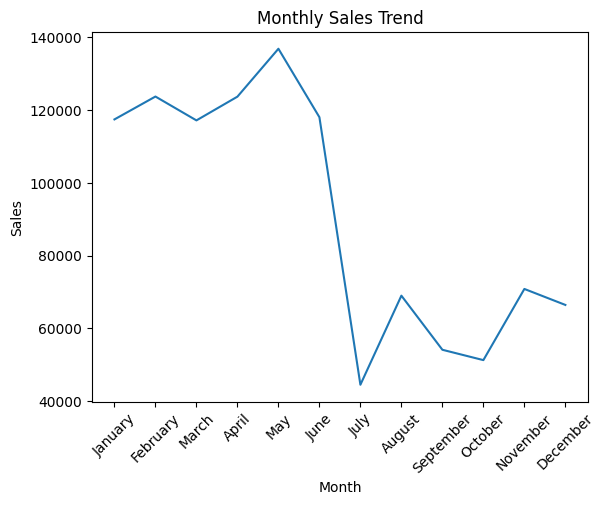

In [99]:
# Import plotting library
import matplotlib.pyplot as plt

# Create line chart
plt.plot(monthly_sales.index.get_level_values('Order_Month_Name'), monthly_sales.values)

# Rotate month labels
plt.xticks(rotation=45)

# Add chart title
plt.title('Monthly Sales Trend')

# Add x-axis label
plt.xlabel('Month')

# Add y-axis label
plt.ylabel('Sales')

# Display chart
plt.show()

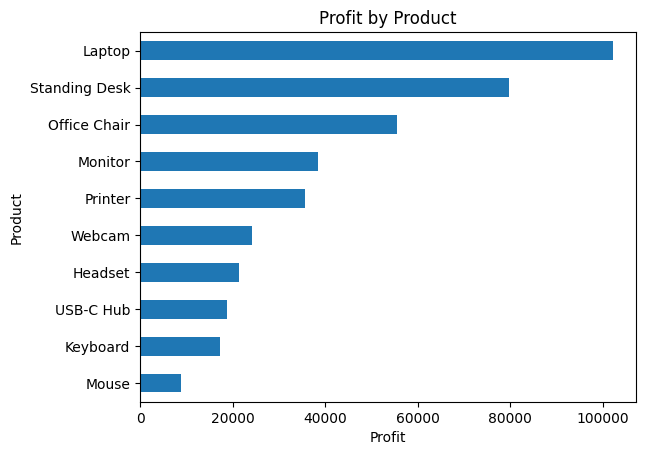

In [100]:
# Create product profit chart
product_profit.sort_values().plot(kind='barh')

# Add chart title
plt.title('Profit by Product')

# Add x-axis label
plt.xlabel('Profit')

# Add y-axis label
plt.ylabel('Product')

# Display chart
plt.show()

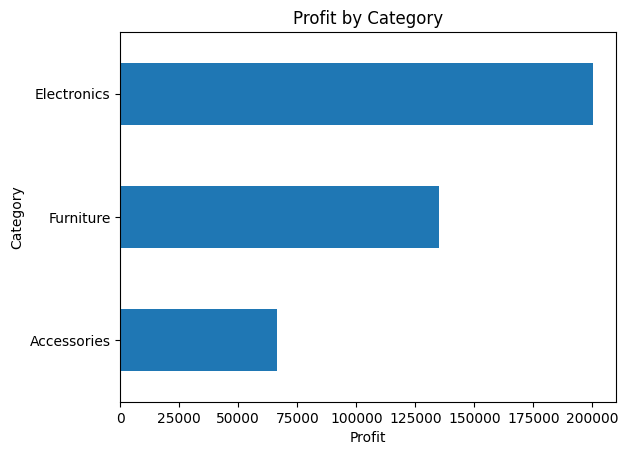

In [101]:
# Sort category profit
category_profit_chart = category_profit.sort_values()

# Create horizontal bar chart
category_profit_chart.plot(kind='barh')

# Add chart title
plt.title('Profit by Category')

# Add x-axis label
plt.xlabel('Profit')

# Add y-axis label
plt.ylabel('Category')

# Display chart
plt.show()

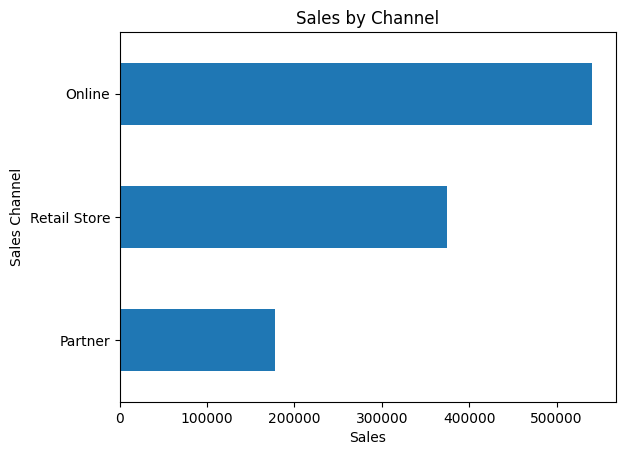

In [102]:
# Sort channel sales
channel_sales_chart = channel_summary['Sales'].sort_values()

# Create horizontal bar chart
channel_sales_chart.plot(kind='barh')

# Add chart title
plt.title('Sales by Channel')

# Add x-axis label
plt.xlabel('Sales')

# Add y-axis label
plt.ylabel('Sales Channel')

# Display chart
plt.show()

In [106]:
# Export cleaned dataset
sales_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Sales_data_analysis/cleaned_sales_data.csv', index=False)

# Confirm export
print('Cleaned dataset exported successfully.')

Cleaned dataset exported successfully.


In [108]:
# Set export folder
export_path = '/content/drive/MyDrive/Colab Notebooks/Sales_data_analysis/'

# Export regional sales
region_sales.to_csv(export_path + 'region_sales_summary.csv')

# Export category summary
category_summary.to_csv(export_path + 'category_summary.csv')

# Export channel summary
channel_summary.to_csv(export_path + 'channel_summary.csv')

# Export customer segment summary
segment_summary.to_csv(export_path + 'customer_segment_summary.csv')

# Export product summary
product_summary.to_csv(export_path + 'product_summary.csv')

# Export cleaned dataset
sales_df.to_csv(export_path + 'cleaned_sales_data.csv', index=False)

# Confirm exports
print('All project files exported successfully.')

All project files exported successfully.
